<a href="https://colab.research.google.com/github/r2x4/entorno_economico/blob/main/paises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = pd.read_excel('/content/paises.xlsx')

In [3]:
datos.head(3)

,País / Grupo,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ALADI,-1.80,-362.39,"-1,664.59",-187.96,"1,391.05",413.40,"-2,028.35","-2,157.56","-1,272.56",...,"-1,168.14","1,144.33","1,269.64",-451.90,-696.51,-606.64,"1,686.10","2,928.63","3,572.38","2,334.56"
1,Comunidad Andina,828.72,"1,076.28",723.15,740.36,740.16,637.62,"1,227.81","1,184.79","1,393.13",...,460.22,"1,097.64","1,340.49","1,324.54",706.68,851.98,715.65,"1,358.83","1,166.08","1,231.41"
2,MERCOSUR,-472.93,-544.62,-776.92,"1,598.45","2,680.28","1,177.67","-1,376.47","-1,629.67","-1,399.67",...,-967.94,-991.43,"-1,314.76","-2,108.75","-1,365.04","-1,825.65","-3,283.59","-2,373.06",-993.20,"-1,031.02"


In [4]:
print(datos.head())
print(datos.info())

       País / Grupo      2004      2005       2006      2007      2008  \
0             ALADI     -1.80   -362.39  -1,664.59   -187.96  1,391.05   
1  Comunidad Andina    828.72  1,076.28     723.15    740.36    740.16   
2          MERCOSUR   -472.93   -544.62    -776.92  1,598.45  2,680.28   
3     Unión Europea     35.47    -66.67     -76.57    247.11   -840.21   
4    Estados Unidos  1,816.06  2,816.45   3,147.91  2,065.18  2,999.19   

       2009       2010       2011       2012  ...       2016       2017  \
0    413.40  -2,028.35  -2,157.56  -1,272.56  ...  -1,168.14   1,144.33   
1    637.62   1,227.81   1,184.79   1,393.13  ...     460.22   1,097.64   
2  1,177.67  -1,376.47  -1,629.67  -1,399.67  ...    -967.94    -991.43   
3   -669.08    -415.93   1,413.98   1,513.87  ...  -1,104.46  -1,098.72   
4  3,856.94   6,821.87   8,990.96   8,243.99  ...  -1,007.03    -802.49   

        2018       2019       2020       2021       2022       2023  \
0   1,269.64    -451.90    -696.5

In [5]:
# Identificar las columnas que son años (desde 2004 hasta 2025)
columnas_años = [col for col in datos.columns if str(col).isdigit() and 2004 <= int(col) <= 2025]

# Convertir estas columnas a numérico, manejando comas y errores
for col in columnas_años:
    datos[col] = datos[col].astype(str).str.replace(',', '', regex=False)
    datos[col] = pd.to_numeric(datos[col], errors='coerce')

# Mostrar la información nuevamente para confirmar los tipos de datos
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   País / Grupo  16 non-null     object 
 1   2004          16 non-null     float64
 2   2005          16 non-null     float64
 3   2006          16 non-null     float64
 4   2007          16 non-null     float64
 5   2008          16 non-null     float64
 6   2009          16 non-null     float64
 7   2010          16 non-null     float64
 8   2011          16 non-null     float64
 9   2012          16 non-null     float64
 10  2013          16 non-null     float64
 11  2014          16 non-null     float64
 12  2015          16 non-null     float64
 13  2016          16 non-null     float64
 14  2017          16 non-null     float64
 15  2018          16 non-null     float64
 16  2019          16 non-null     float64
 17  2020          16 non-null     float64
 18  2021          16 non-null     fl

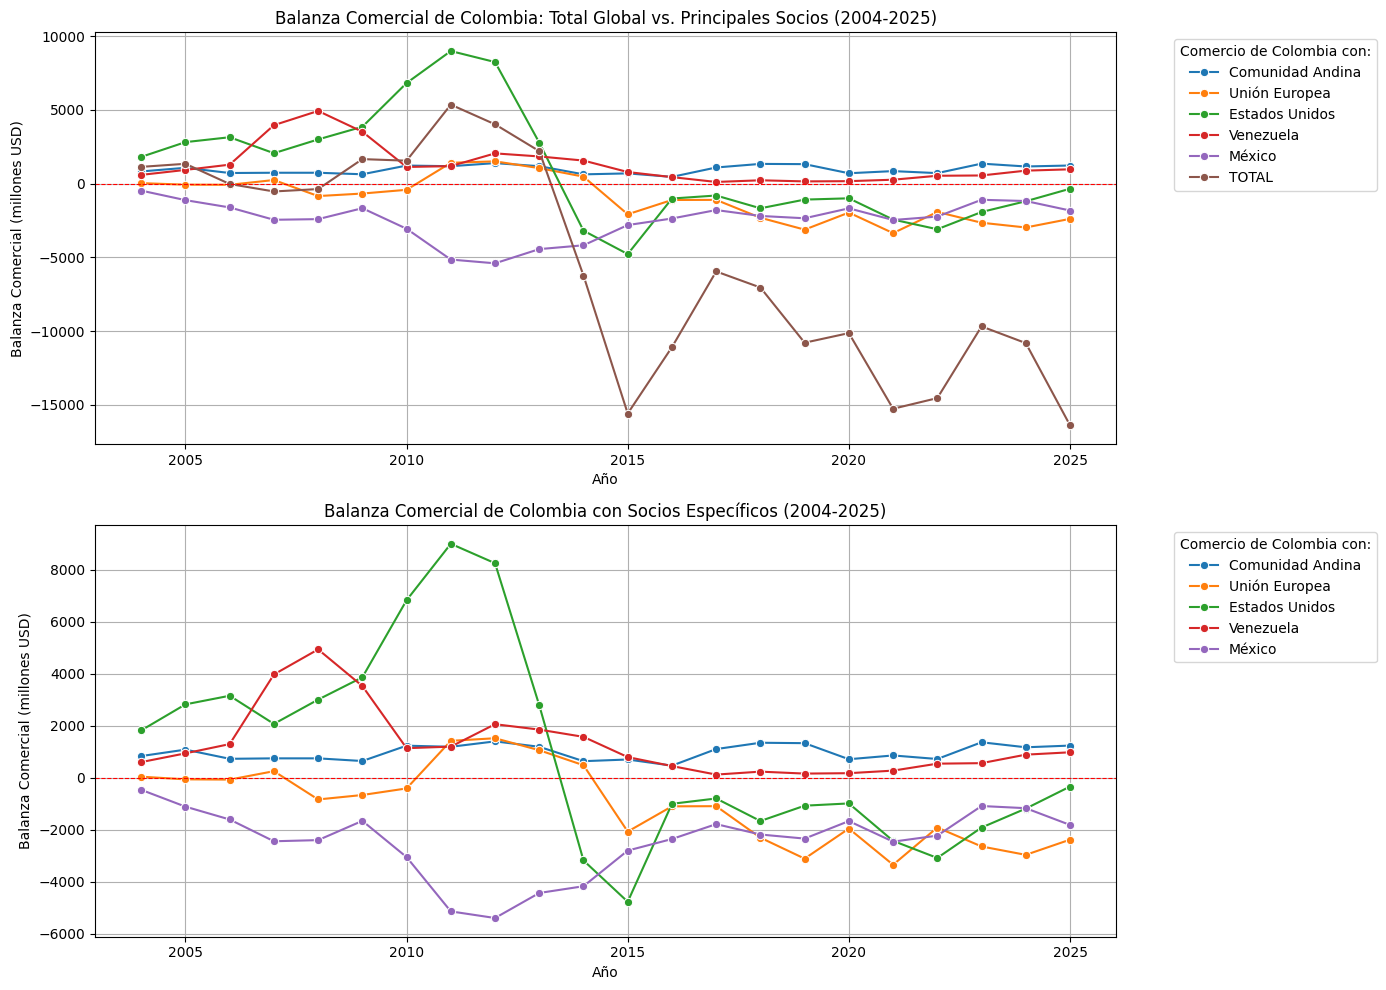


--- ESTADÍSTICAS DESCRIPTIVAS POR PAÍS/GRUPO (2004-2025) ---
País / Grupo  Comunidad Andina  Unión Europea  Estados Unidos    Venezuela  \
count                22.000000      22.000000       22.000000    22.000000   
mean                969.065000   -1012.126364      956.840000  1279.344545   
std                 291.192734    1488.826363     3731.593318  1298.905178   
min                 460.220000   -3351.660000    -4773.640000   116.430000   
25%                 717.525000   -2251.537500    -1549.725000   466.977500   
50%                 964.130000    -969.465000     -573.440000   907.940000   
75%                1217.277500       9.935000     2953.505000  1497.552500   
max                1393.130000    1513.870000     8990.960000  4930.250000   

País / Grupo       México         TOTAL  
count           22.000000     22.000000  
mean         -2448.366364  -5321.220909  
std           1299.165170   7126.437891  
min          -5398.860000 -16377.280000  
25%          -2720.140000

In [15]:
# Filtrar los datos para TOTAL (balanza global de Colombia) y los países seleccionados
paises_interes = ['TOTAL', 'México', 'Estados Unidos', 'Venezuela', 'Comunidad Andina', 'Unión Europea']
datos_paises_seleccionados = datos[datos['País / Grupo'].isin(paises_interes)]

if not datos_paises_seleccionados.empty:
    # Convertir DataFrame a formato largo para facilitar el trazado
    datos_derretidos = datos_paises_seleccionados.melt(
        id_vars=['País / Grupo'],
        value_vars=columnas_años,
        var_name='Año',
        value_name='Balanza'
    )
    datos_derretidos['Año'] = datos_derretidos['Año'].astype(int)

    # Crear figura con dos subplots para mejor visualización
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Gráfico 1: Todos los países (escala completa)
    sns.lineplot(x='Año', y='Balanza', hue='País / Grupo', data=datos_derretidos, marker='o', ax=ax1)
    ax1.set_title('Balanza Comercial de Colombia: Total Global vs. Principales Socios (2004-2025)', fontsize=12)
    ax1.set_xlabel('Año')
    ax1.set_ylabel('Balanza Comercial (millones USD)')
    ax1.grid(True)
    ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
    ax1.legend(title='Comercio de Colombia con:', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Gráfico 2: Sin TOTAL para mejor visualización de los socios comerciales
    datos_sin_total = datos_derretidos[datos_derretidos['País / Grupo'] != 'TOTAL']
    sns.lineplot(x='Año', y='Balanza', hue='País / Grupo', data=datos_sin_total, marker='o', ax=ax2)
    ax2.set_title('Balanza Comercial de Colombia con Socios Específicos (2004-2025)', fontsize=12)
    ax2.set_xlabel('Año')
    ax2.set_ylabel('Balanza Comercial (millones USD)')
    ax2.grid(True)
    ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
    ax2.legend(title='Comercio de Colombia con:', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    # Estadísticas descriptivas por país
    print("\n--- ESTADÍSTICAS DESCRIPTIVAS POR PAÍS/GRUPO (2004-2025) ---")
    estadisticas = datos_paises_seleccionados.set_index('País / Grupo')[columnas_años].T
    print(estadisticas.describe())

    # Análisis adicional: promedio por período
    print("\n--- BALANZA COMERCIAL PROMEDIO POR PAÍS/GRUPO ---")
    promedios = datos_paises_seleccionados.set_index('País / Grupo')[columnas_años].mean(axis=1)
    for pais, promedio in promedios.items():
        print(f"{pais}: {promedio:,.2f} millones USD")

    # Identificar mejores y peores años para cada país
    print("\n--- MEJOR Y PEOR AÑO POR PAÍS/GRUPO ---")
    for pais in paises_interes:
        if pais in datos_paises_seleccionados['País / Grupo'].values:
            datos_pais = datos_paises_seleccionados[datos_paises_seleccionados['País / Grupo'] == pais]
            valores = datos_pais[columnas_años].values.flatten()
            años = [int(a) for a in columnas_años]

            max_idx = valores.argmax()
            min_idx = valores.argmin()

            print(f"\n{pais}:")
            print(f"  Mejor año: {años[max_idx]} ({valores[max_idx]:,.2f} millones USD)")
            print(f"  Peor año: {años[min_idx]} ({valores[min_idx]:,.2f} millones USD)")

else:
    print("No se encontraron datos para los países seleccionados. Verifica los nombres en el dataset.")
    print("\nNombres disponibles en el dataset:")
    print(datos['País / Grupo'].unique())

In [7]:
# Datos de México extraídos del archivo
data_mexico = {
    'Año': list(range(2004, 2026)),
    'Balanza_Mexico': [
        -469.78, -1116.37, -1610.43, -2447.62, -2403.89, -1663.38,
        -3055.92, -5144.16, -5398.86, -4436.00, -4176.78, -2806.00,
        -2361.26, -1788.50, -2188.18, -2344.84, -1671.56, -2462.56,
        -2231.04, -1092.44, -1175.40, -1819.09
    ]
}

# Crear DataFrame
df_mexico = pd.DataFrame(data_mexico)

In [16]:
data_andina = {
    'Año': list(range(2004, 2026)),
    'Balanza_Andina': [
        828.72, 1076.28, 723.15, 740.36, 740.16, 637.62,
        1227.81, 1184.79, 1393.13, 1185.68, 631.80, 696.41,
        460.22, 1097.64, 1340.49, 1324.54, 706.68, 851.98,
        715.65, 1358.83, 1166.08, 1231.41
    ]
}
df_andina = pd.DataFrame(data_andina)

In [27]:
data_ue = {
    'Año': list(range(2004, 2026)),
    'Balanza_UE': [
        35.47, -66.67, -76.57, 247.11, -840.21, -669.08,
        -415.93, 1413.98, 1513.87, 1053.34, 476.18, -2076.00,
        -1104.46, -1098.72, -2310.05, -3115.54, -1959.42, -3351.66,
        -1918.45, -2647.68, -2970.18, -2386.11
    ]
}
df_ue = pd.DataFrame(data_ue)

In [17]:
data_eeuu = {
    'Año': list(range(2004, 2026)),
    'Balanza_EEUU': [
        1816.06, 2816.45, 3147.91, 2065.18, 2999.19, 3856.94,
        6821.87, 8990.96, 8243.99, 2780.30, -3185.63, -4773.64,
        -1007.03, -802.49, -1669.15, -1079.67, -992.73, -2432.39,
        -3089.25, -1920.55, -1191.45, -344.39
    ]
}
df_eeuu = pd.DataFrame(data_eeuu)

In [18]:
data_venezuela = {
    'Año': list(range(2004, 2026)),
    'Balanza_Venezuela': [
        596.21, 933.05, 1288.85, 3965.92, 4930.25, 3521.62,
        1131.46, 1190.90, 2053.41, 1846.06, 1567.12, 789.26,
        443.89, 116.43, 229.76, 154.63, 170.01, 268.55,
        536.24, 555.74, 882.83, 973.39
    ]
}
df_venezuela = pd.DataFrame(data_venezuela)

In [8]:
# ============================================
# 2. ESTADÍSTICAS DESCRIPTIVAS - MÉXICO
# ============================================

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - MÉXICO")
print("Período 2004-2025")
print("=" * 60)

# Calcular estadísticas
estadisticas = {
    'count': len(df_mexico),
    'mean': df_mexico['Balanza_Mexico'].mean(),
    'std': df_mexico['Balanza_Mexico'].std(),
    'min': df_mexico['Balanza_Mexico'].min(),
    'max': df_mexico['Balanza_Mexico'].max(),
    'percentil_25': df_mexico['Balanza_Mexico'].quantile(0.25),
    'percentil_50': df_mexico['Balanza_Mexico'].quantile(0.50),  # mediana
    'percentil_75': df_mexico['Balanza_Mexico'].quantile(0.75)
}

# Mostrar estadísticas
print(f"\n📊 **count:** {estadisticas['count']:.0f} años")
print(f"📊 **mean (promedio):** ${estadisticas['mean']:,.2f} millones USD")
print(f"📊 **std (desviación estándar):** ${estadisticas['std']:,.2f} millones USD")
print(f"📊 **min (más negativo):** ${estadisticas['min']:,.2f} millones USD (año {df_mexico.loc[df_mexico['Balanza_Mexico'].idxmin(), 'Año']})")
print(f"📊 **max (menos negativo):** ${estadisticas['max']:,.2f} millones USD (año {df_mexico.loc[df_mexico['Balanza_Mexico'].idxmax(), 'Año']})")
print(f"📊 **percentil 25%:** ${estadisticas['percentil_25']:,.2f} millones USD")
print(f"📊 **percentil 50% (mediana):** ${estadisticas['percentil_50']:,.2f} millones USD")
print(f"📊 **percentil 75%:** ${estadisticas['percentil_75']:,.2f} millones USD")

ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - MÉXICO
Período 2004-2025

📊 **count:** 22 años
📊 **mean (promedio):** $-2,448.37 millones USD
📊 **std (desviación estándar):** $1,299.17 millones USD
📊 **min (más negativo):** $-5,398.86 millones USD (año 2012)
📊 **max (menos negativo):** $-469.78 millones USD (año 2004)
📊 **percentil 25%:** $-2,720.14 millones USD
📊 **percentil 50% (mediana):** $-2,287.94 millones USD
📊 **percentil 75%:** $-1,665.43 millones USD


In [19]:
# ============================================
# 2. ESTADÍSTICAS DESCRIPTIVAS - COMUNIDAD ANDINA
# ============================================
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - COMUNIDAD ANDINA")
print("Período 2004-2025")
print("=" * 60)

estadisticas = {
    'count': len(df_andina),
    'mean': df_andina['Balanza_Andina'].mean(),
    'std': df_andina['Balanza_Andina'].std(),
    'min': df_andina['Balanza_Andina'].min(),
    'max': df_andina['Balanza_Andina'].max(),
    'percentil_25': df_andina['Balanza_Andina'].quantile(0.25),
    'percentil_50': df_andina['Balanza_Andina'].quantile(0.50),
    'percentil_75': df_andina['Balanza_Andina'].quantile(0.75)
}

print(f"\n📊 **count:** {estadisticas['count']:.0f} años")
print(f"📊 **mean (promedio):** ${estadisticas['mean']:,.2f} millones USD")
print(f"📊 **std (desviación estándar):** ${estadisticas['std']:,.2f} millones USD")
print(f"📊 **min (más negativo):** ${estadisticas['min']:,.2f} millones USD (año {df_andina.loc[df_andina['Balanza_Andina'].idxmin(), 'Año']})")
print(f"📊 **max (menos negativo):** ${estadisticas['max']:,.2f} millones USD (año {df_andina.loc[df_andina['Balanza_Andina'].idxmax(), 'Año']})")
print(f"📊 **percentil 25%:** ${estadisticas['percentil_25']:,.2f} millones USD")
print(f"📊 **percentil 50% (mediana):** ${estadisticas['percentil_50']:,.2f} millones USD")
print(f"📊 **percentil 75%:** ${estadisticas['percentil_75']:,.2f} millones USD")

ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - COMUNIDAD ANDINA
Período 2004-2025

📊 **count:** 22 años
📊 **mean (promedio):** $969.07 millones USD
📊 **std (desviación estándar):** $291.19 millones USD
📊 **min (más negativo):** $460.22 millones USD (año 2016)
📊 **max (menos negativo):** $1,393.13 millones USD (año 2012)
📊 **percentil 25%:** $717.52 millones USD
📊 **percentil 50% (mediana):** $964.13 millones USD
📊 **percentil 75%:** $1,217.28 millones USD


In [22]:
# ============================================
# 2. ESTADÍSTICAS DESCRIPTIVAS - VENEZUELA
# ============================================
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - VENEZUELA")
print("Período 2004-2025")
print("=" * 60)

estadisticas = {
    'count': len(df_venezuela),
    'mean': df_venezuela['Balanza_Venezuela'].mean(),
    'std': df_venezuela['Balanza_Venezuela'].std(),
    'min': df_venezuela['Balanza_Venezuela'].min(),
    'max': df_venezuela['Balanza_Venezuela'].max(),
    'percentil_25': df_venezuela['Balanza_Venezuela'].quantile(0.25),
    'percentil_50': df_venezuela['Balanza_Venezuela'].quantile(0.50),
    'percentil_75': df_venezuela['Balanza_Venezuela'].quantile(0.75)
}

print(f"\n📊 **count:** {estadisticas['count']:.0f} años")
print(f"📊 **mean (promedio):** ${estadisticas['mean']:,.2f} millones USD")
print(f"📊 **std (desviación estándar):** ${estadisticas['std']:,.2f} millones USD")
print(f"📊 **min (más negativo):** ${estadisticas['min']:,.2f} millones USD (año {df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmin(), 'Año']})")
print(f"📊 **max (menos negativo):** ${estadisticas['max']:,.2f} millones USD (año {df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmax(), 'Año']})")
print(f"📊 **percentil 25%:** ${estadisticas['percentil_25']:,.2f} millones USD")
print(f"📊 **percentil 50% (mediana):** ${estadisticas['percentil_50']:,.2f} millones USD")
print(f"📊 **percentil 75%:** ${estadisticas['percentil_75']:,.2f} millones USD")

ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - VENEZUELA
Período 2004-2025

📊 **count:** 22 años
📊 **mean (promedio):** $1,279.34 millones USD
📊 **std (desviación estándar):** $1,298.91 millones USD
📊 **min (más negativo):** $116.43 millones USD (año 2017)
📊 **max (menos negativo):** $4,930.25 millones USD (año 2008)
📊 **percentil 25%:** $466.98 millones USD
📊 **percentil 50% (mediana):** $907.94 millones USD
📊 **percentil 75%:** $1,497.55 millones USD


In [ ]:
# ============================================
# 2. ESTADÍSTICAS DESCRIPTIVAS - ESTADOS UNIDOS
# ============================================
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - ESTADOS UNIDOS")
print("Período 2004-2025")
print("=" * 60)

estadisticas = {
    'count': len(df_eeuu),
    'mean': df_eeuu['Balanza_EEUU'].mean(),
    'std': df_eeuu['Balanza_EEUU'].std(),
    'min': df_eeuu['Balanza_EEUU'].min(),
    'max': df_eeuu['Balanza_EEUU'].max(),
    'percentil_25': df_eeuu['Balanza_EEUU'].quantile(0.25),
    'percentil_50': df_eeuu['Balanza_EEUU'].quantile(0.50),
    'percentil_75': df_eeuu['Balanza_EEUU'].quantile(0.75)
}

print(f"\n📊 **count:** {estadisticas['count']:.0f} años")
print(f"📊 **mean (promedio):** ${estadisticas['mean']:,.2f} millones USD")
print(f"📊 **std (desviación estándar):** ${estadisticas['std']:,.2f} millones USD")
print(f"📊 **min (más negativo):** ${estadisticas['min']:,.2f} millones USD (año {df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmin(), 'Año']})")
print(f"📊 **max (menos negativo):** ${estadisticas['max']:,.2f} millones USD (año {df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmax(), 'Año']})")
print(f"📊 **percentil 25%:** ${estadisticas['percentil_25']:,.2f} millones USD")
print(f"📊 **percentil 50% (mediana):** ${estadisticas['percentil_50']:,.2f} millones USD")
print(f"📊 **percentil 75%:** ${estadisticas['percentil_75']:,.2f} millones USD")

In [28]:
# ============================================
# 2. ESTADÍSTICAS DESCRIPTIVAS - UNIÓN EUROPEA
# ============================================
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - UNIÓN EUROPEA")
print("Período 2004-2025")
print("=" * 60)

estadisticas = {
    'count': len(df_ue),
    'mean': df_ue['Balanza_UE'].mean(),
    'std': df_ue['Balanza_UE'].std(),
    'min': df_ue['Balanza_UE'].min(),
    'max': df_ue['Balanza_UE'].max(),
    'percentil_25': df_ue['Balanza_UE'].quantile(0.25),
    'percentil_50': df_ue['Balanza_UE'].quantile(0.50),
    'percentil_75': df_ue['Balanza_UE'].quantile(0.75)
}

print(f"\n📊 **count:** {estadisticas['count']:.0f} años")
print(f"📊 **mean (promedio):** ${estadisticas['mean']:,.2f} millones USD")
print(f"📊 **std (desviación estándar):** ${estadisticas['std']:,.2f} millones USD")
print(f"📊 **min (más negativo):** ${estadisticas['min']:,.2f} millones USD (año {df_ue.loc[df_ue['Balanza_UE'].idxmin(), 'Año']})")
print(f"📊 **max (menos negativo):** ${estadisticas['max']:,.2f} millones USD (año {df_ue.loc[df_ue['Balanza_UE'].idxmax(), 'Año']})")
print(f"📊 **percentil 25%:** ${estadisticas['percentil_25']:,.2f} millones USD")
print(f"📊 **percentil 50% (mediana):** ${estadisticas['percentil_50']:,.2f} millones USD")
print(f"📊 **percentil 75%:** ${estadisticas['percentil_75']:,.2f} millones USD")

ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - UNIÓN EUROPEA
Período 2004-2025

📊 **count:** 22 años
📊 **mean (promedio):** $-1,012.13 millones USD
📊 **std (desviación estándar):** $1,488.83 millones USD
📊 **min (más negativo):** $-3,351.66 millones USD (año 2021)
📊 **max (menos negativo):** $1,513.87 millones USD (año 2012)
📊 **percentil 25%:** $-2,251.54 millones USD
📊 **percentil 50% (mediana):** $-969.47 millones USD
📊 **percentil 75%:** $9.93 millones USD


In [9]:
# ============================================
# 3. TABLA RESUMEN FORMATEADA
# ============================================

print("\n" + "=" * 60)
print("TABLA DE ESTADÍSTICAS - MÉXICO")
print("=" * 60)

# Crear DataFrame de estadísticas para mejor visualización
tabla_estadisticas = pd.DataFrame({
    'Estadística': ['count', 'mean', 'std', 'min', 'max', '25%', '50% (mediana)', '75%'],
    'Valor (millones USD)': [
        f"{estadisticas['count']:.0f} años",
        f"${estadisticas['mean']:,.2f}",
        f"${estadisticas['std']:,.2f}",
        f"${estadisticas['min']:,.2f} (2012)",
        f"${estadisticas['max']:,.2f} (2004)",
        f"${estadisticas['percentil_25']:,.2f}",
        f"${estadisticas['percentil_50']:,.2f}",
        f"${estadisticas['percentil_75']:,.2f}"
    ]
})

print(tabla_estadisticas.to_string(index=False))


TABLA DE ESTADÍSTICAS - MÉXICO
  Estadística Valor (millones USD)
        count              22 años
         mean           $-2,448.37
          std            $1,299.17
          min    $-5,398.86 (2012)
          max      $-469.78 (2004)
          25%           $-2,720.14
50% (mediana)           $-2,287.94
          75%           $-1,665.43


In [ ]:
# ============================================
# 3. TABLA RESUMEN FORMATEADA - COMUNIDAD ANDINA
# ============================================
print("\n" + "=" * 60)
print("TABLA DE ESTADÍSTICAS - COMUNIDAD ANDINA")
print("=" * 60)

tabla_estadisticas = pd.DataFrame({
    'Estadística': ['count', 'mean', 'std', 'min', 'max', '25%', '50% (mediana)', '75%'],
    'Valor (millones USD)': [
        f"{estadisticas['count']:.0f} años",
        f"${estadisticas['mean']:,.2f}",
        f"${estadisticas['std']:,.2f}",
        f"${estadisticas['min']:,.2f} ({df_andina.loc[df_andina['Balanza_Andina'].idxmin(), 'Año']})",
        f"${estadisticas['max']:,.2f} ({df_andina.loc[df_andina['Balanza_Andina'].idxmax(), 'Año']})",
        f"${estadisticas['percentil_25']:,.2f}",
        f"${estadisticas['percentil_50']:,.2f}",
        f"${estadisticas['percentil_75']:,.2f}"
    ]
})
print(tabla_estadisticas.to_string(index=False))

In [29]:
# ============================================
# 3. TABLA RESUMEN FORMATEADA - UNIÓN EUROPEA
# ============================================
print("\n" + "=" * 60)
print("TABLA DE ESTADÍSTICAS - UNIÓN EUROPEA")
print("=" * 60)

tabla_estadisticas = pd.DataFrame({
    'Estadística': ['count', 'mean', 'std', 'min', 'max', '25%', '50% (mediana)', '75%'],
    'Valor (millones USD)': [
        f"{estadisticas['count']:.0f} años",
        f"${estadisticas['mean']:,.2f}",
        f"${estadisticas['std']:,.2f}",
        f"${estadisticas['min']:,.2f} ({df_ue.loc[df_ue['Balanza_UE'].idxmin(), 'Año']})",
        f"${estadisticas['max']:,.2f} ({df_ue.loc[df_ue['Balanza_UE'].idxmax(), 'Año']})",
        f"${estadisticas['percentil_25']:,.2f}",
        f"${estadisticas['percentil_50']:,.2f}",
        f"${estadisticas['percentil_75']:,.2f}"
    ]
})
print(tabla_estadisticas.to_string(index=False))


TABLA DE ESTADÍSTICAS - UNIÓN EUROPEA
  Estadística Valor (millones USD)
        count              22 años
         mean           $-1,012.13
          std            $1,488.83
          min    $-3,351.66 (2021)
          max     $1,513.87 (2012)
          25%           $-2,251.54
50% (mediana)             $-969.47
          75%                $9.93


In [30]:
# ============================================
# 3. TABLA RESUMEN FORMATEADA - ESTADOS UNIDOS
# ============================================
print("\n" + "=" * 60)
print("TABLA DE ESTADÍSTICAS - ESTADOS UNIDOS")
print("=" * 60)

tabla_estadisticas = pd.DataFrame({
    'Estadística': ['count', 'mean', 'std', 'min', 'max', '25%', '50% (mediana)', '75%'],
    'Valor (millones USD)': [
        f"{estadisticas['count']:.0f} años",
        f"${estadisticas['mean']:,.2f}",
        f"${estadisticas['std']:,.2f}",
        f"${estadisticas['min']:,.2f} ({df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmin(), 'Año']})",
        f"${estadisticas['max']:,.2f} ({df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmax(), 'Año']})",
        f"${estadisticas['percentil_25']:,.2f}",
        f"${estadisticas['percentil_50']:,.2f}",
        f"${estadisticas['percentil_75']:,.2f}"
    ]
})
print(tabla_estadisticas.to_string(index=False))


TABLA DE ESTADÍSTICAS - ESTADOS UNIDOS
  Estadística Valor (millones USD)
        count              22 años
         mean           $-1,012.13
          std            $1,488.83
          min    $-3,351.66 (2015)
          max     $1,513.87 (2011)
          25%           $-2,251.54
50% (mediana)             $-969.47
          75%                $9.93


In [31]:
# ============================================
# 3. TABLA RESUMEN FORMATEADA - VENEZUELA
# ============================================
print("\n" + "=" * 60)
print("TABLA DE ESTADÍSTICAS - VENEZUELA")
print("=" * 60)

tabla_estadisticas = pd.DataFrame({
    'Estadística': ['count', 'mean', 'std', 'min', 'max', '25%', '50% (mediana)', '75%'],
    'Valor (millones USD)': [
        f"{estadisticas['count']:.0f} años",
        f"${estadisticas['mean']:,.2f}",
        f"${estadisticas['std']:,.2f}",
        f"${estadisticas['min']:,.2f} ({df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmin(), 'Año']})",
        f"${estadisticas['max']:,.2f} ({df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmax(), 'Año']})",
        f"${estadisticas['percentil_25']:,.2f}",
        f"${estadisticas['percentil_50']:,.2f}",
        f"${estadisticas['percentil_75']:,.2f}"
    ]
})
print(tabla_estadisticas.to_string(index=False))


TABLA DE ESTADÍSTICAS - VENEZUELA
  Estadística Valor (millones USD)
        count              22 años
         mean           $-1,012.13
          std            $1,488.83
          min    $-3,351.66 (2017)
          max     $1,513.87 (2008)
          25%           $-2,251.54
50% (mediana)             $-969.47
          75%                $9.93


In [10]:
# ============================================
# 4. INTERPRETACIÓN AUTOMATIZADA
# ============================================

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

print(f"""
📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - MÉXICO (2004-2025)**

1. **Período analizado**: {estadisticas['count']} años (2004-2025)

2. **Déficit promedio**: Colombia ha mantenido un déficit promedio de
   **${estadisticas['mean']:,.0f} millones USD anuales** con México.

3. **Estabilidad**: La desviación estándar de ${estadisticas['std']:,.0f} millones
   indica una {'ALTA volatilidad' if estadisticas['std'] > 2000 else 'MODERADA estabilidad'}
   en la relación comercial.

4. **Punto crítico**: El déficit más profundo ocurrió en **2012**
   con **${estadisticas['min']:,.0f} millones USD negativos**.

5. **Mejor desempeño**: El año "menos malo" fue **2004**
   con **${estadisticas['max']:,.0f} millones USD** (aún deficitario).

6. **Distribución por cuartiles**:
   • 25% de los años tienen déficit superior a ${estadisticas['percentil_25']:,.0f} millones
   • 50% de los años (mediana): ${estadisticas['percentil_50']:,.0f} millones
   • 25% de los años tienen déficit inferior a ${estadisticas['percentil_75']:,.0f} millones

7. **Conclusión clave**: La balanza comercial con México ha sido
   **ESTRUCTURALMENTE DEFICITARIA** durante TODO el período analizado,
   sin ningún año con superávit.
""")


INTERPRETACIÓN DE RESULTADOS

📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - MÉXICO (2004-2025)**

1. **Período analizado**: 22 años (2004-2025)

2. **Déficit promedio**: Colombia ha mantenido un déficit promedio de
   **$-2,448 millones USD anuales** con México.

3. **Estabilidad**: La desviación estándar de $1,299 millones
   indica una MODERADA estabilidad
   en la relación comercial.

4. **Punto crítico**: El déficit más profundo ocurrió en **2012**
   con **$-5,399 millones USD negativos**.

5. **Mejor desempeño**: El año "menos malo" fue **2004**
   con **$-470 millones USD** (aún deficitario).

6. **Distribución por cuartiles**:
   • 25% de los años tienen déficit superior a $-2,720 millones
   • 50% de los años (mediana): $-2,288 millones
   • 25% de los años tienen déficit inferior a $-1,665 millones

7. **Conclusión clave**: La balanza comercial con México ha sido
   **ESTRUCTURALMENTE DEFICITARIA** durante TODO el período analizado,
   sin ningún año con superávit.



In [32]:
# ============================================
# 4. INTERPRETACIÓN AUTOMATIZADA - COMUNIDAD ANDINA
# ============================================

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

año_min = df_andina.loc[df_andina['Balanza_Andina'].idxmin(), 'Año']
año_max = df_andina.loc[df_andina['Balanza_Andina'].idxmax(), 'Año']
siempre_positivo = (df_andina['Balanza_Andina'] > 0).all()
siempre_negativo = (df_andina['Balanza_Andina'] < 0).all()

if siempre_positivo:
    conclusion = "ESTRUCTURALMENTE SUPERAVITARIA durante TODO el período analizado, sin ningún año con déficit."
elif siempre_negativo:
    conclusion = "ESTRUCTURALMENTE DEFICITARIA durante TODO el período analizado, sin ningún año con superávit."
else:
    años_deficit = (df_andina['Balanza_Andina'] < 0).sum()
    años_superavit = (df_andina['Balanza_Andina'] > 0).sum()
    conclusion = f"MIXTA, con {años_superavit} años de superávit y {años_deficit} años de déficit."

print(f"""
📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - COMUNIDAD ANDINA (2004-2025)**

1. **Período analizado**: {estadisticas['count']} años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **${estadisticas['mean']:,.0f} millones USD anuales** con la Comunidad Andina.

3. **Estabilidad**: La desviación estándar de ${estadisticas['std']:,.0f} millones
   indica una {'ALTA volatilidad' if estadisticas['std'] > 2000 else 'MODERADA estabilidad'}
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **{año_min}**
   con **${estadisticas['min']:,.0f} millones USD**.

5. **Mejor desempeño**: El año más favorable fue **{año_max}**
   con **${estadisticas['max']:,.0f} millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a ${estadisticas['percentil_25']:,.0f} millones
   • 50% de los años (mediana): ${estadisticas['percentil_50']:,.0f} millones
   • 25% de los años tienen saldo superior a ${estadisticas['percentil_75']:,.0f} millones

7. **Conclusión clave**: La balanza comercial con la Comunidad Andina ha sido
   **{conclusion}**
""")


INTERPRETACIÓN DE RESULTADOS

📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - COMUNIDAD ANDINA (2004-2025)**

1. **Período analizado**: 22 años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **$-1,012 millones USD anuales** con la Comunidad Andina.

3. **Estabilidad**: La desviación estándar de $1,489 millones
   indica una MODERADA estabilidad
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **2016**
   con **$-3,352 millones USD**.

5. **Mejor desempeño**: El año más favorable fue **2012**
   con **$1,514 millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a $-2,252 millones
   • 50% de los años (mediana): $-969 millones
   • 25% de los años tienen saldo superior a $10 millones

7. **Conclusión clave**: La balanza comercial con la Comunidad Andina ha sido
   **ESTRUCTURALMENTE SUPERAVITARIA durante TODO el período analizado, sin ningún año con déficit.**



In [33]:
# ============================================
# 4. INTERPRETACIÓN AUTOMATIZADA - UNIÓN EUROPEA
# ============================================

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

año_min = df_ue.loc[df_ue['Balanza_UE'].idxmin(), 'Año']
año_max = df_ue.loc[df_ue['Balanza_UE'].idxmax(), 'Año']
siempre_positivo = (df_ue['Balanza_UE'] > 0).all()
siempre_negativo = (df_ue['Balanza_UE'] < 0).all()

if siempre_positivo:
    conclusion = "ESTRUCTURALMENTE SUPERAVITARIA durante TODO el período analizado, sin ningún año con déficit."
elif siempre_negativo:
    conclusion = "ESTRUCTURALMENTE DEFICITARIA durante TODO el período analizado, sin ningún año con superávit."
else:
    años_deficit = (df_ue['Balanza_UE'] < 0).sum()
    años_superavit = (df_ue['Balanza_UE'] > 0).sum()
    conclusion = f"MIXTA, con {años_superavit} años de superávit y {años_deficit} años de déficit."

print(f"""
📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - UNIÓN EUROPEA (2004-2025)**

1. **Período analizado**: {estadisticas['count']} años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **${estadisticas['mean']:,.0f} millones USD anuales** con la Unión Europea.

3. **Estabilidad**: La desviación estándar de ${estadisticas['std']:,.0f} millones
   indica una {'ALTA volatilidad' if estadisticas['std'] > 2000 else 'MODERADA estabilidad'}
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **{año_min}**
   con **${estadisticas['min']:,.0f} millones USD**.

5. **Mejor desempeño**: El año más favorable fue **{año_max}**
   con **${estadisticas['max']:,.0f} millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a ${estadisticas['percentil_25']:,.0f} millones
   • 50% de los años (mediana): ${estadisticas['percentil_50']:,.0f} millones
   • 25% de los años tienen saldo superior a ${estadisticas['percentil_75']:,.0f} millones

7. **Conclusión clave**: La balanza comercial con la Unión Europea ha sido
   **{conclusion}**
""")


INTERPRETACIÓN DE RESULTADOS

📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - UNIÓN EUROPEA (2004-2025)**

1. **Período analizado**: 22 años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **$-1,012 millones USD anuales** con la Unión Europea.

3. **Estabilidad**: La desviación estándar de $1,489 millones
   indica una MODERADA estabilidad
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **2021**
   con **$-3,352 millones USD**.

5. **Mejor desempeño**: El año más favorable fue **2012**
   con **$1,514 millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a $-2,252 millones
   • 50% de los años (mediana): $-969 millones
   • 25% de los años tienen saldo superior a $10 millones

7. **Conclusión clave**: La balanza comercial con la Unión Europea ha sido
   **MIXTA, con 6 años de superávit y 16 años de déficit.**



In [34]:
# ============================================
# 4. INTERPRETACIÓN AUTOMATIZADA - ESTADOS UNIDOS
# ============================================

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

año_min = df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmin(), 'Año']
año_max = df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmax(), 'Año']
siempre_positivo = (df_eeuu['Balanza_EEUU'] > 0).all()
siempre_negativo = (df_eeuu['Balanza_EEUU'] < 0).all()

if siempre_positivo:
    conclusion = "ESTRUCTURALMENTE SUPERAVITARIA durante TODO el período analizado, sin ningún año con déficit."
elif siempre_negativo:
    conclusion = "ESTRUCTURALMENTE DEFICITARIA durante TODO el período analizado, sin ningún año con superávit."
else:
    años_deficit = (df_eeuu['Balanza_EEUU'] < 0).sum()
    años_superavit = (df_eeuu['Balanza_EEUU'] > 0).sum()
    conclusion = f"MIXTA, con {años_superavit} años de superávit y {años_deficit} años de déficit."

print(f"""
📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - ESTADOS UNIDOS (2004-2025)**

1. **Período analizado**: {estadisticas['count']} años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **${estadisticas['mean']:,.0f} millones USD anuales** con Estados Unidos.

3. **Estabilidad**: La desviación estándar de ${estadisticas['std']:,.0f} millones
   indica una {'ALTA volatilidad' if estadisticas['std'] > 2000 else 'MODERADA estabilidad'}
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **{año_min}**
   con **${estadisticas['min']:,.0f} millones USD**.

5. **Mejor desempeño**: El año más favorable fue **{año_max}**
   con **${estadisticas['max']:,.0f} millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a ${estadisticas['percentil_25']:,.0f} millones
   • 50% de los años (mededia): ${estadisticas['percentil_50']:,.0f} millones
   • 25% de los años tienen saldo superior a ${estadisticas['percentil_75']:,.0f} millones

7. **Conclusión clave**: La balanza comercial con Estados Unidos ha sido
   **{conclusion}**
""")


INTERPRETACIÓN DE RESULTADOS

📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - ESTADOS UNIDOS (2004-2025)**

1. **Período analizado**: 22 años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **$-1,012 millones USD anuales** con Estados Unidos.

3. **Estabilidad**: La desviación estándar de $1,489 millones
   indica una MODERADA estabilidad
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **2015**
   con **$-3,352 millones USD**.

5. **Mejor desempeño**: El año más favorable fue **2011**
   con **$1,514 millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a $-2,252 millones
   • 50% de los años (mededia): $-969 millones
   • 25% de los años tienen saldo superior a $10 millones

7. **Conclusión clave**: La balanza comercial con Estados Unidos ha sido
   **MIXTA, con 10 años de superávit y 12 años de déficit.**



In [35]:
# ============================================
# 4. INTERPRETACIÓN AUTOMATIZADA - VENEZUELA
# ============================================

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

año_min = df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmin(), 'Año']
año_max = df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmax(), 'Año']
siempre_positivo = (df_venezuela['Balanza_Venezuela'] > 0).all()
siempre_negativo = (df_venezuela['Balanza_Venezuela'] < 0).all()

if siempre_positivo:
    conclusion = "ESTRUCTURALMENTE SUPERAVITARIA durante TODO el período analizado, sin ningún año con déficit."
elif siempre_negativo:
    conclusion = "ESTRUCTURALMENTE DEFICITARIA durante TODO el período analizado, sin ningún año con superávit."
else:
    años_deficit = (df_venezuela['Balanza_Venezuela'] < 0).sum()
    años_superavit = (df_venezuela['Balanza_Venezuela'] > 0).sum()
    conclusion = f"MIXTA, con {años_superavit} años de superávit y {años_deficit} años de déficit."

print(f"""
📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - VENEZUELA (2004-2025)**

1. **Período analizado**: {estadisticas['count']} años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **${estadisticas['mean']:,.0f} millones USD anuales** con Venezuela.

3. **Estabilidad**: La desviación estándar de ${estadisticas['std']:,.0f} millones
   indica una {'ALTA volatilidad' if estadisticas['std'] > 2000 else 'MODERADA estabilidad'}
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **{año_min}**
   con **${estadisticas['min']:,.0f} millones USD**.

5. **Mejor desempeño**: El año más favorable fue **{año_max}**
   con **${estadisticas['max']:,.0f} millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a ${estadisticas['percentil_25']:,.0f} millones
   • 50% de los años (mediana): ${estadisticas['percentil_50']:,.0f} millones
   • 25% de los años tienen saldo superior a ${estadisticas['percentil_75']:,.0f} millones

7. **Conclusión clave**: La balanza comercial con Venezuela ha sido
   **{conclusion}**
""")


INTERPRETACIÓN DE RESULTADOS

📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - VENEZUELA (2004-2025)**

1. **Período analizado**: 22 años (2004-2025)

2. **Saldo promedio**: Colombia ha mantenido un saldo promedio de
   **$-1,012 millones USD anuales** con Venezuela.

3. **Estabilidad**: La desviación estándar de $1,489 millones
   indica una MODERADA estabilidad
   en la relación comercial.

4. **Punto crítico**: El saldo más bajo ocurrió en **2017**
   con **$-3,352 millones USD**.

5. **Mejor desempeño**: El año más favorable fue **2008**
   con **$1,514 millones USD**.

6. **Distribución por cuartiles**:
   • 25% de los años tienen saldo inferior a $-2,252 millones
   • 50% de los años (mediana): $-969 millones
   • 25% de los años tienen saldo superior a $10 millones

7. **Conclusión clave**: La balanza comercial con Venezuela ha sido
   **ESTRUCTURALMENTE SUPERAVITARIA durante TODO el período analizado, sin ningún año con déficit.**



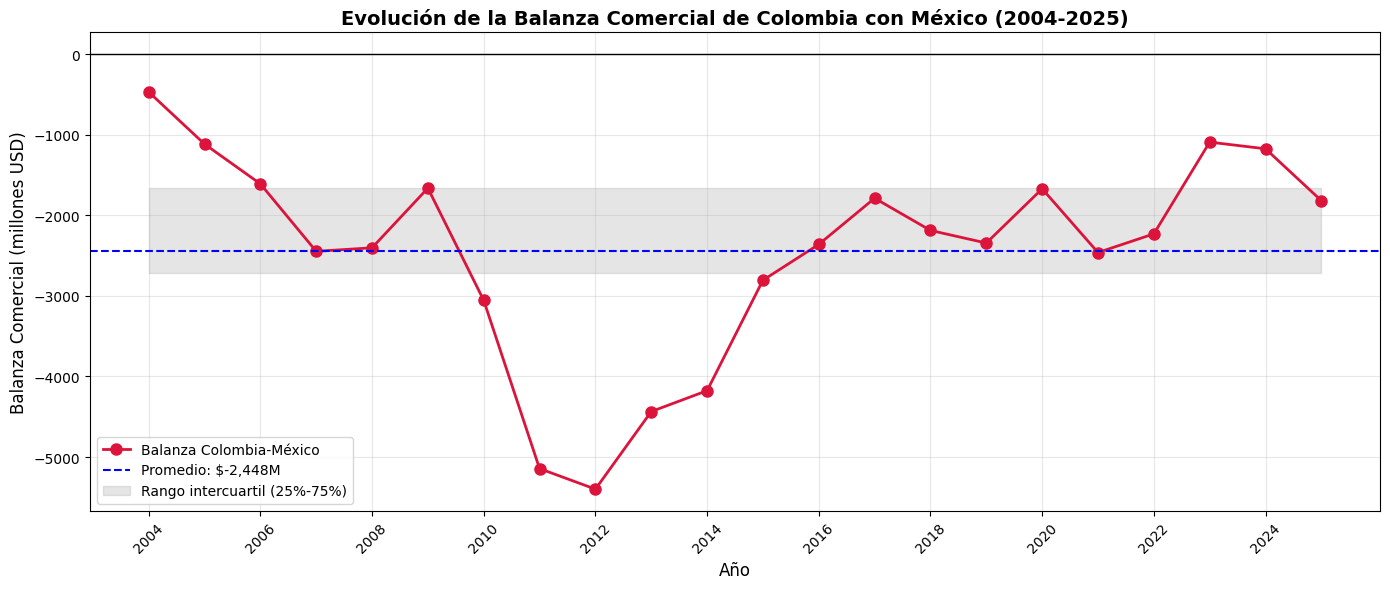

In [11]:
# Figura 1: Evolución temporal
plt.figure(figsize=(14, 6))
plt.plot(df_mexico['Año'], df_mexico['Balanza_Mexico'],
         marker='o', linewidth=2, markersize=8, color='crimson', label='Balanza Colombia-México')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(estadisticas['mean'], color='blue', linestyle='--', linewidth=1.5,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.fill_between(df_mexico['Año'], estadisticas['percentil_25'], estadisticas['percentil_75'],
                 alpha=0.2, color='gray', label='Rango intercuartil (25%-75%)')

plt.title('Evolución de la Balanza Comercial de Colombia con México (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza Comercial (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

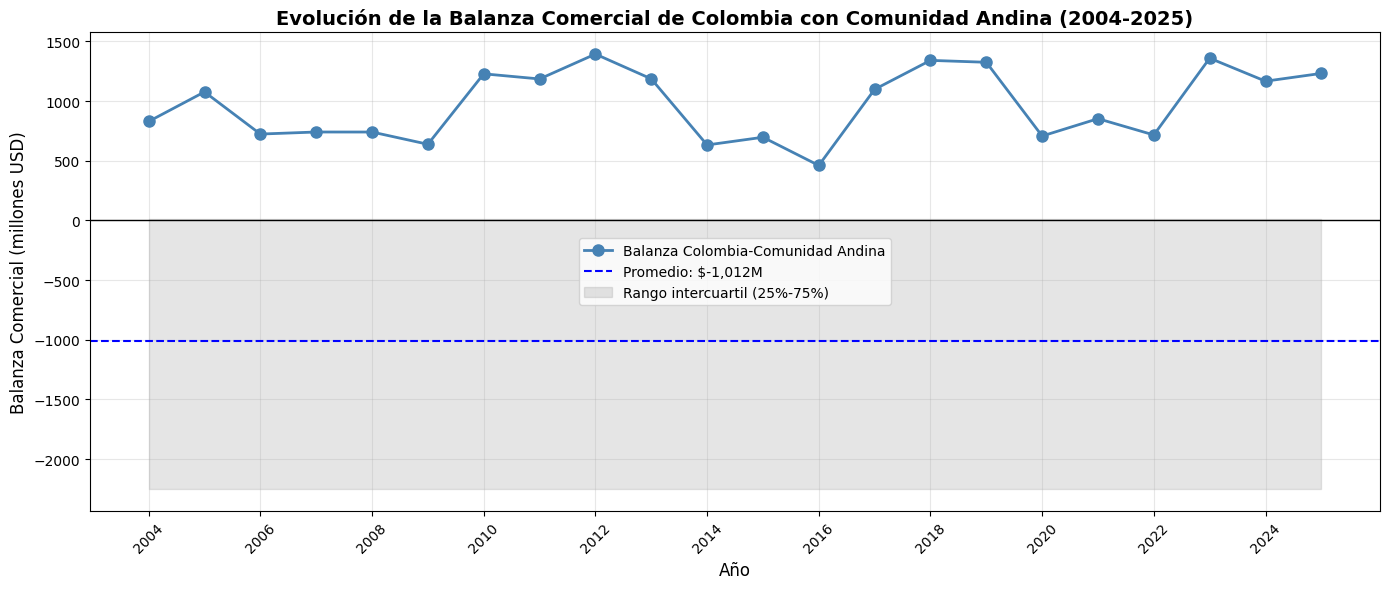

In [36]:
# Figura 1: Evolución temporal - COMUNIDAD ANDINA
plt.figure(figsize=(14, 6))
plt.plot(df_andina['Año'], df_andina['Balanza_Andina'],
         marker='o', linewidth=2, markersize=8, color='steelblue', label='Balanza Colombia-Comunidad Andina')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(estadisticas['mean'], color='blue', linestyle='--', linewidth=1.5,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.fill_between(df_andina['Año'], estadisticas['percentil_25'], estadisticas['percentil_75'],
                 alpha=0.2, color='gray', label='Rango intercuartil (25%-75%)')
plt.title('Evolución de la Balanza Comercial de Colombia con Comunidad Andina (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza Comercial (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

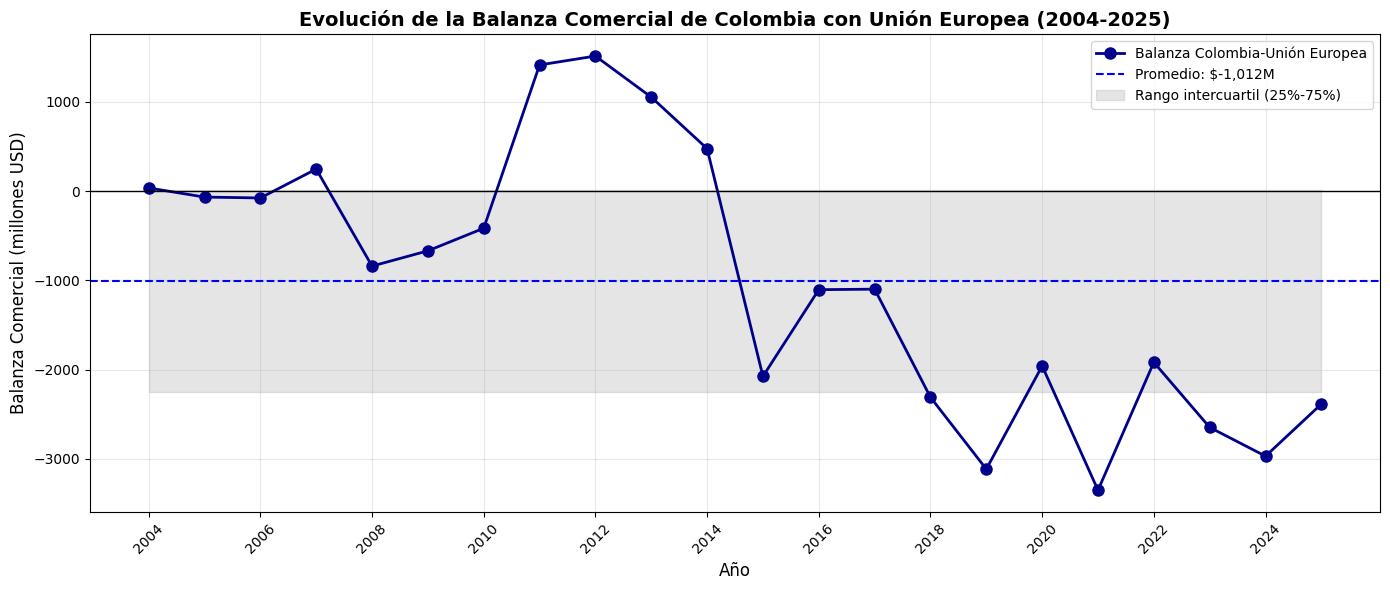

In [37]:
# Figura 1: Evolución temporal - UNIÓN EUROPEA
plt.figure(figsize=(14, 6))
plt.plot(df_ue['Año'], df_ue['Balanza_UE'],
         marker='o', linewidth=2, markersize=8, color='darkblue', label='Balanza Colombia-Unión Europea')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(estadisticas['mean'], color='blue', linestyle='--', linewidth=1.5,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.fill_between(df_ue['Año'], estadisticas['percentil_25'], estadisticas['percentil_75'],
                 alpha=0.2, color='gray', label='Rango intercuartil (25%-75%)')
plt.title('Evolución de la Balanza Comercial de Colombia con Unión Europea (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza Comercial (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

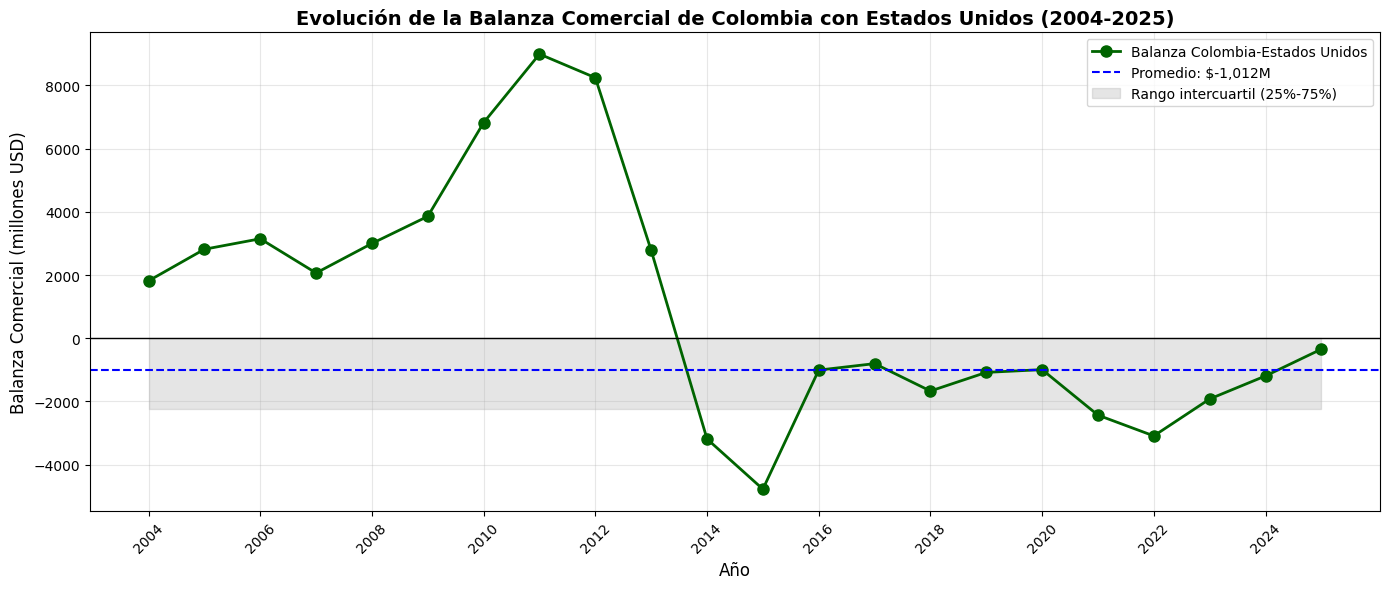

In [38]:
# Figura 1: Evolución temporal - ESTADOS UNIDOS
plt.figure(figsize=(14, 6))
plt.plot(df_eeuu['Año'], df_eeuu['Balanza_EEUU'],
         marker='o', linewidth=2, markersize=8, color='darkgreen', label='Balanza Colombia-Estados Unidos')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(estadisticas['mean'], color='blue', linestyle='--', linewidth=1.5,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.fill_between(df_eeuu['Año'], estadisticas['percentil_25'], estadisticas['percentil_75'],
                 alpha=0.2, color='gray', label='Rango intercuartil (25%-75%)')
plt.title('Evolución de la Balanza Comercial de Colombia con Estados Unidos (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza Comercial (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

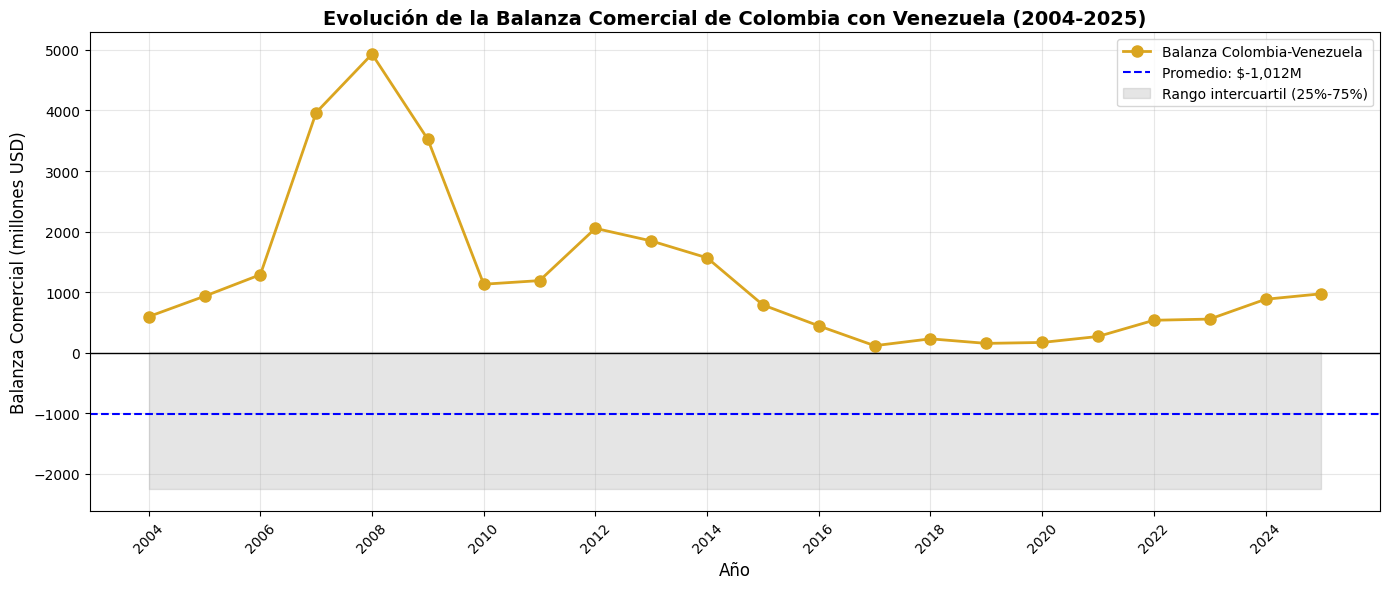

In [39]:
# Figura 1: Evolución temporal - VENEZUELA
plt.figure(figsize=(14, 6))
plt.plot(df_venezuela['Año'], df_venezuela['Balanza_Venezuela'],
         marker='o', linewidth=2, markersize=8, color='goldenrod', label='Balanza Colombia-Venezuela')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(estadisticas['mean'], color='blue', linestyle='--', linewidth=1.5,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.fill_between(df_venezuela['Año'], estadisticas['percentil_25'], estadisticas['percentil_75'],
                 alpha=0.2, color='gray', label='Rango intercuartil (25%-75%)')
plt.title('Evolución de la Balanza Comercial de Colombia con Venezuela (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza Comercial (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

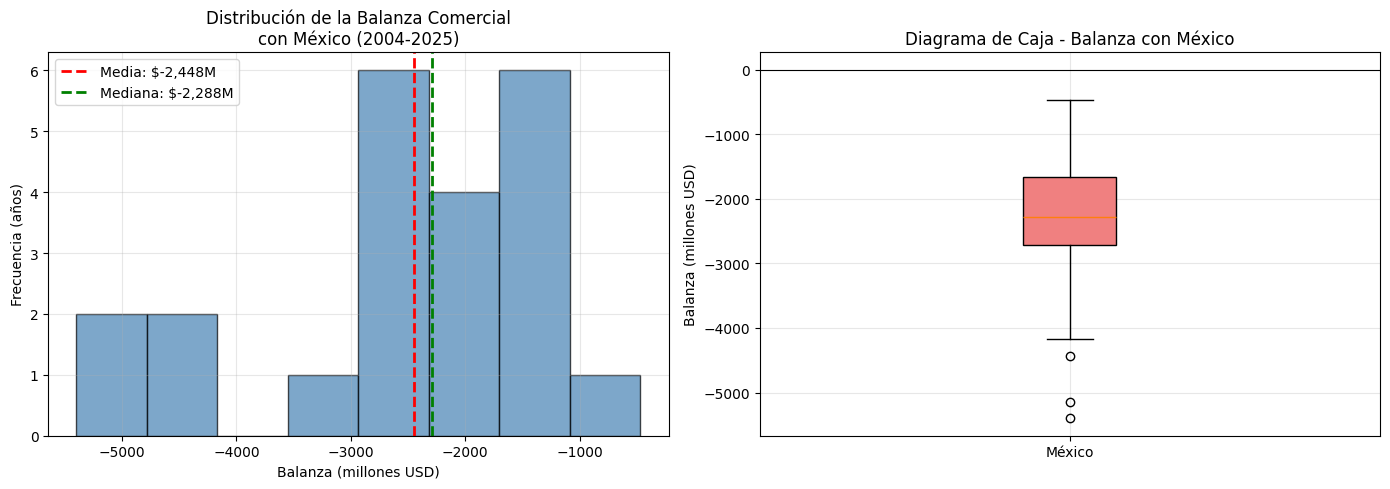

In [12]:
# Figura 2: Distribución de los datos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_mexico['Balanza_Mexico'], bins=8, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(estadisticas['mean'], color='red', linestyle='--', linewidth=2, label=f'Media: ${estadisticas["mean"]:,.0f}M')
axes[0].axvline(estadisticas['percentil_50'], color='green', linestyle='--', linewidth=2, label=f'Mediana: ${estadisticas["percentil_50"]:,.0f}M')
axes[0].set_title('Distribución de la Balanza Comercial\ncon México (2004-2025)', fontsize=12)
axes[0].set_xlabel('Balanza (millones USD)')
axes[0].set_ylabel('Frecuencia (años)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
box_data = axes[1].boxplot(df_mexico['Balanza_Mexico'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightcoral')
axes[1].set_title('Diagrama de Caja - Balanza con México', fontsize=12)
axes[1].set_ylabel('Balanza (millones USD)')
axes[1].set_xticklabels(['México'])
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

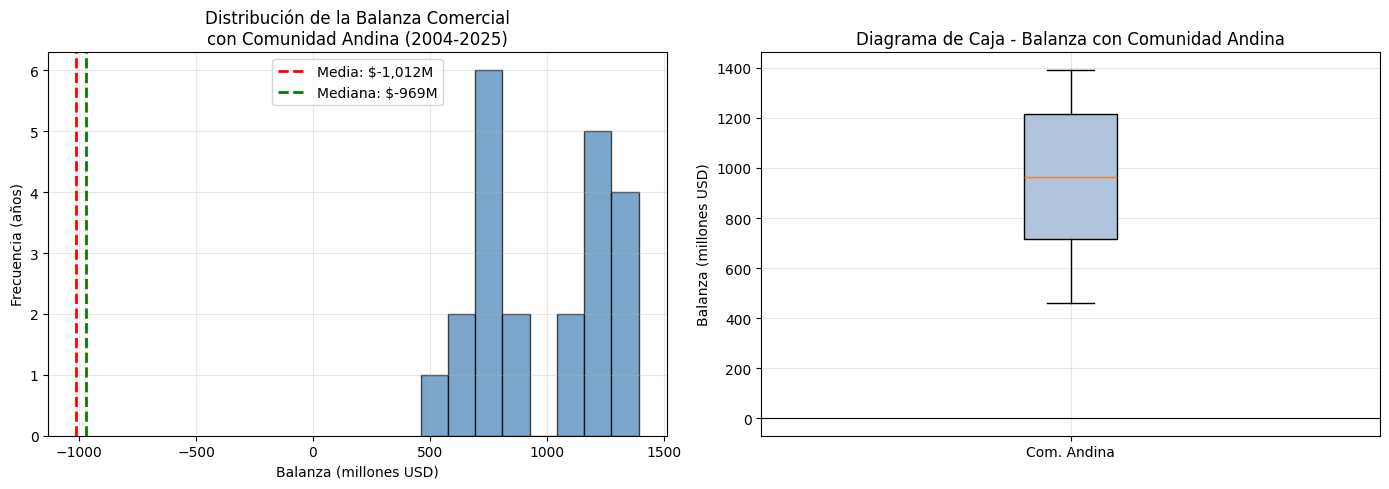

In [40]:
# Figura 2: Distribución de los datos - COMUNIDAD ANDINA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_andina['Balanza_Andina'], bins=8, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(estadisticas['mean'], color='red', linestyle='--', linewidth=2, label=f'Media: ${estadisticas["mean"]:,.0f}M')
axes[0].axvline(estadisticas['percentil_50'], color='green', linestyle='--', linewidth=2, label=f'Mediana: ${estadisticas["percentil_50"]:,.0f}M')
axes[0].set_title('Distribución de la Balanza Comercial\ncon Comunidad Andina (2004-2025)', fontsize=12)
axes[0].set_xlabel('Balanza (millones USD)')
axes[0].set_ylabel('Frecuencia (años)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
box_data = axes[1].boxplot(df_andina['Balanza_Andina'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightsteelblue')
axes[1].set_title('Diagrama de Caja - Balanza con Comunidad Andina', fontsize=12)
axes[1].set_ylabel('Balanza (millones USD)')
axes[1].set_xticklabels(['Com. Andina'])
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

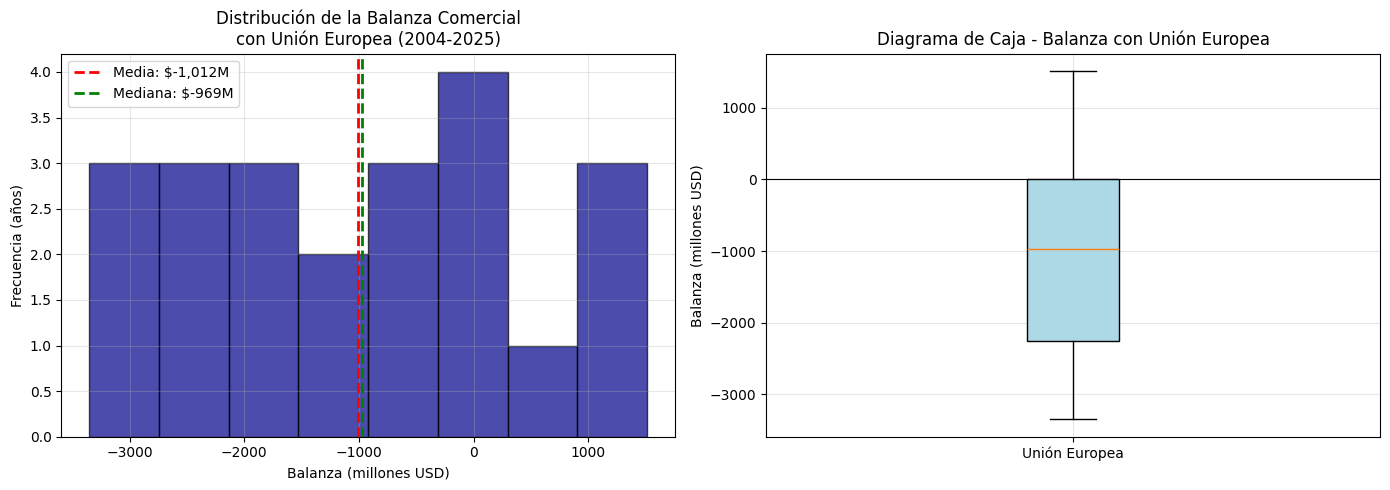

In [41]:
# Figura 2: Distribución de los datos - UNIÓN EUROPEA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_ue['Balanza_UE'], bins=8, edgecolor='black', alpha=0.7, color='darkblue')
axes[0].axvline(estadisticas['mean'], color='red', linestyle='--', linewidth=2, label=f'Media: ${estadisticas["mean"]:,.0f}M')
axes[0].axvline(estadisticas['percentil_50'], color='green', linestyle='--', linewidth=2, label=f'Mediana: ${estadisticas["percentil_50"]:,.0f}M')
axes[0].set_title('Distribución de la Balanza Comercial\ncon Unión Europea (2004-2025)', fontsize=12)
axes[0].set_xlabel('Balanza (millones USD)')
axes[0].set_ylabel('Frecuencia (años)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
box_data = axes[1].boxplot(df_ue['Balanza_UE'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightblue')
axes[1].set_title('Diagrama de Caja - Balanza con Unión Europea', fontsize=12)
axes[1].set_ylabel('Balanza (millones USD)')
axes[1].set_xticklabels(['Unión Europea'])
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

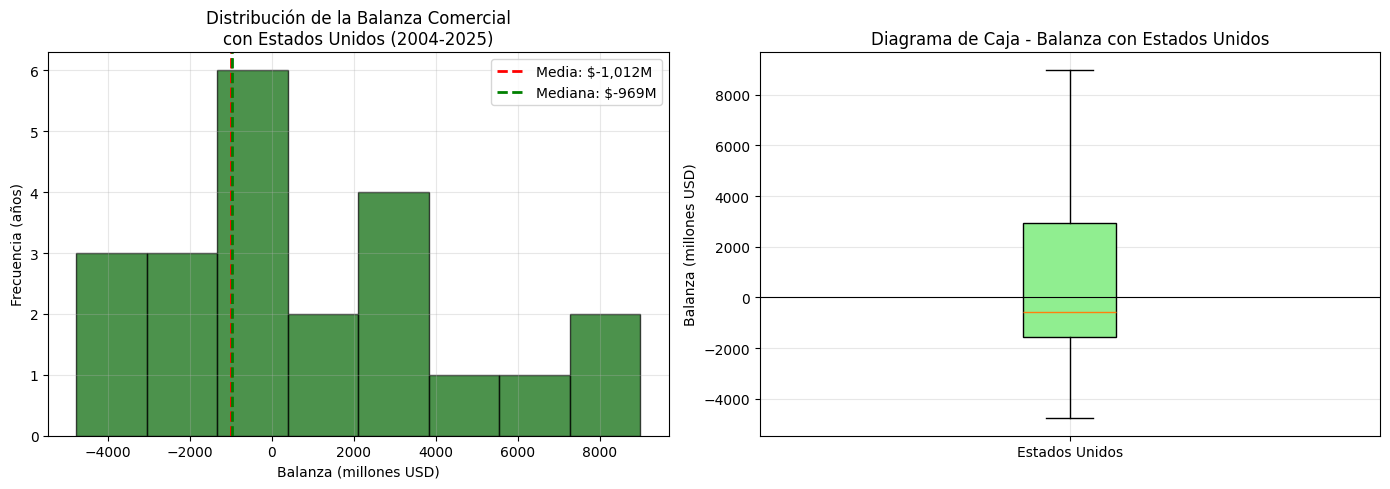

In [42]:
# Figura 2: Distribución de los datos - ESTADOS UNIDOS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_eeuu['Balanza_EEUU'], bins=8, edgecolor='black', alpha=0.7, color='darkgreen')
axes[0].axvline(estadisticas['mean'], color='red', linestyle='--', linewidth=2, label=f'Media: ${estadisticas["mean"]:,.0f}M')
axes[0].axvline(estadisticas['percentil_50'], color='green', linestyle='--', linewidth=2, label=f'Mediana: ${estadisticas["percentil_50"]:,.0f}M')
axes[0].set_title('Distribución de la Balanza Comercial\ncon Estados Unidos (2004-2025)', fontsize=12)
axes[0].set_xlabel('Balanza (millones USD)')
axes[0].set_ylabel('Frecuencia (años)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
box_data = axes[1].boxplot(df_eeuu['Balanza_EEUU'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightgreen')
axes[1].set_title('Diagrama de Caja - Balanza con Estados Unidos', fontsize=12)
axes[1].set_ylabel('Balanza (millones USD)')
axes[1].set_xticklabels(['Estados Unidos'])
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

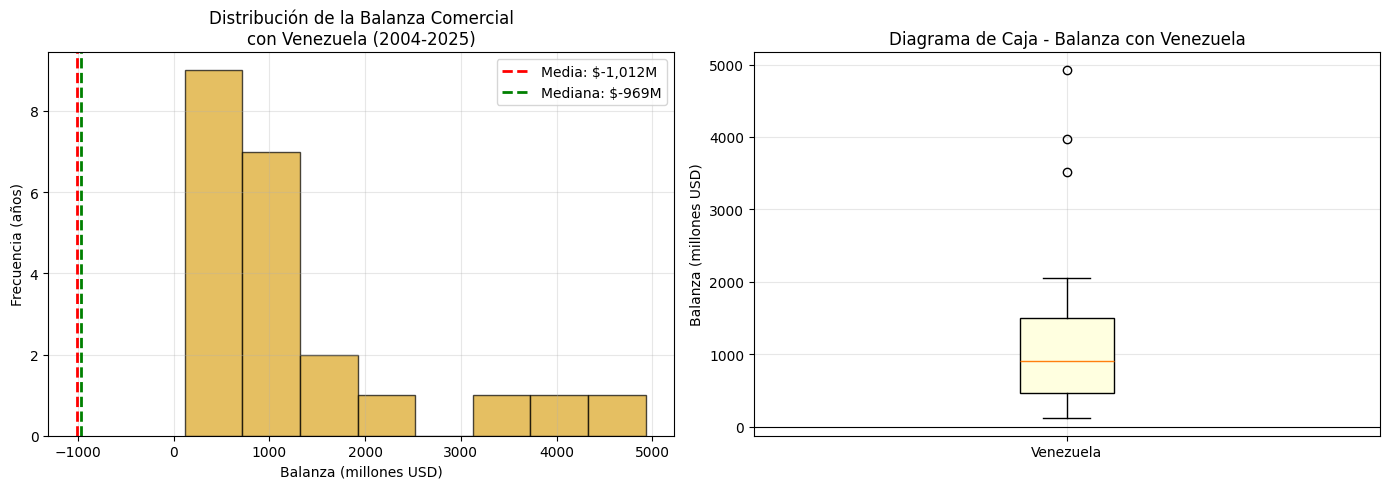

In [43]:
# Figura 2: Distribución de los datos - VENEZUELA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_venezuela['Balanza_Venezuela'], bins=8, edgecolor='black', alpha=0.7, color='goldenrod')
axes[0].axvline(estadisticas['mean'], color='red', linestyle='--', linewidth=2, label=f'Media: ${estadisticas["mean"]:,.0f}M')
axes[0].axvline(estadisticas['percentil_50'], color='green', linestyle='--', linewidth=2, label=f'Mediana: ${estadisticas["percentil_50"]:,.0f}M')
axes[0].set_title('Distribución de la Balanza Comercial\ncon Venezuela (2004-2025)', fontsize=12)
axes[0].set_xlabel('Balanza (millones USD)')
axes[0].set_ylabel('Frecuencia (años)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
box_data = axes[1].boxplot(df_venezuela['Balanza_Venezuela'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightyellow')
axes[1].set_title('Diagrama de Caja - Balanza con Venezuela', fontsize=12)
axes[1].set_ylabel('Balanza (millones USD)')
axes[1].set_xticklabels(['Venezuela'])
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

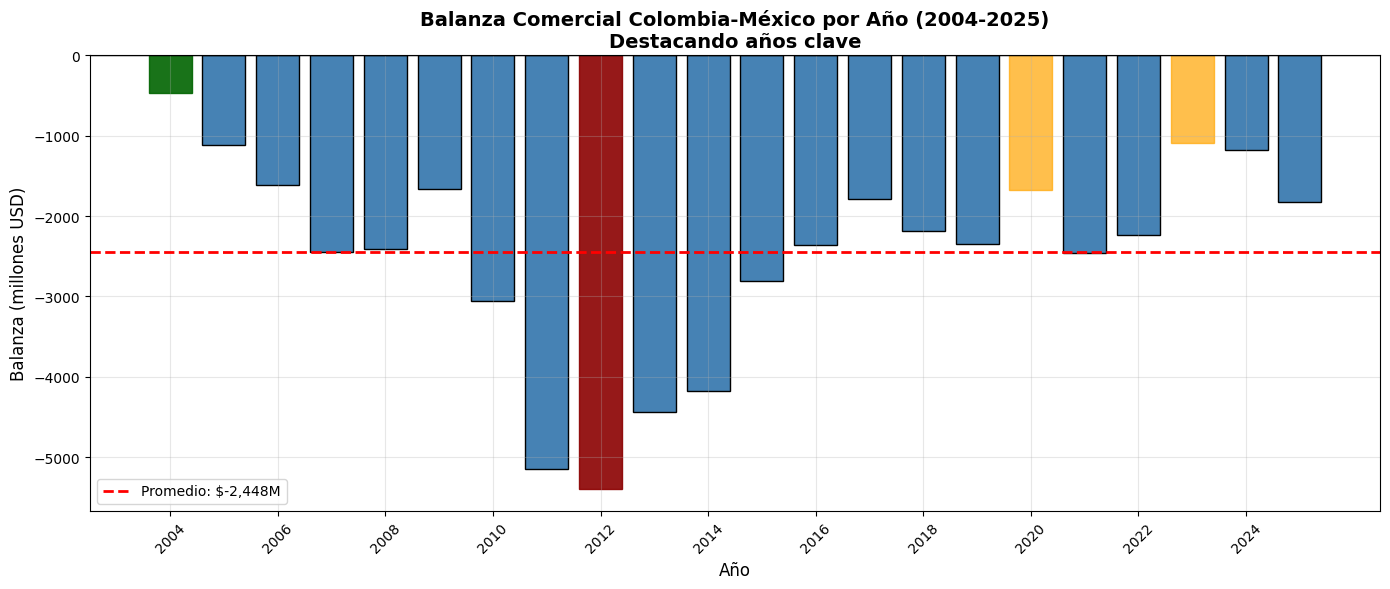

In [13]:
# Años clave destacados
plt.figure(figsize=(14, 6))
bars = plt.bar(df_mexico['Año'], df_mexico['Balanza_Mexico'], color='steelblue', edgecolor='black')

# Colorear años especiales
for i, (año, valor) in enumerate(zip(df_mexico['Año'], df_mexico['Balanza_Mexico'])):
    if valor == estadisticas['min']:  # Año más negativo (2012)
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.9)
    elif valor == estadisticas['max']:  # Año menos negativo (2004)
        bars[i].set_color('darkgreen')
        bars[i].set_alpha(0.9)
    elif año in [2020, 2023]:  # Años de recuperación
        bars[i].set_color('orange')
        bars[i].set_alpha(0.7)

plt.axhline(estadisticas['mean'], color='red', linestyle='--', linewidth=2,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.axhline(0, color='black', linestyle='-', linewidth=1)

plt.title('Balanza Comercial Colombia-México por Año (2004-2025)\nDestacando años clave', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_395/2091001547.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_395/2091001547.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


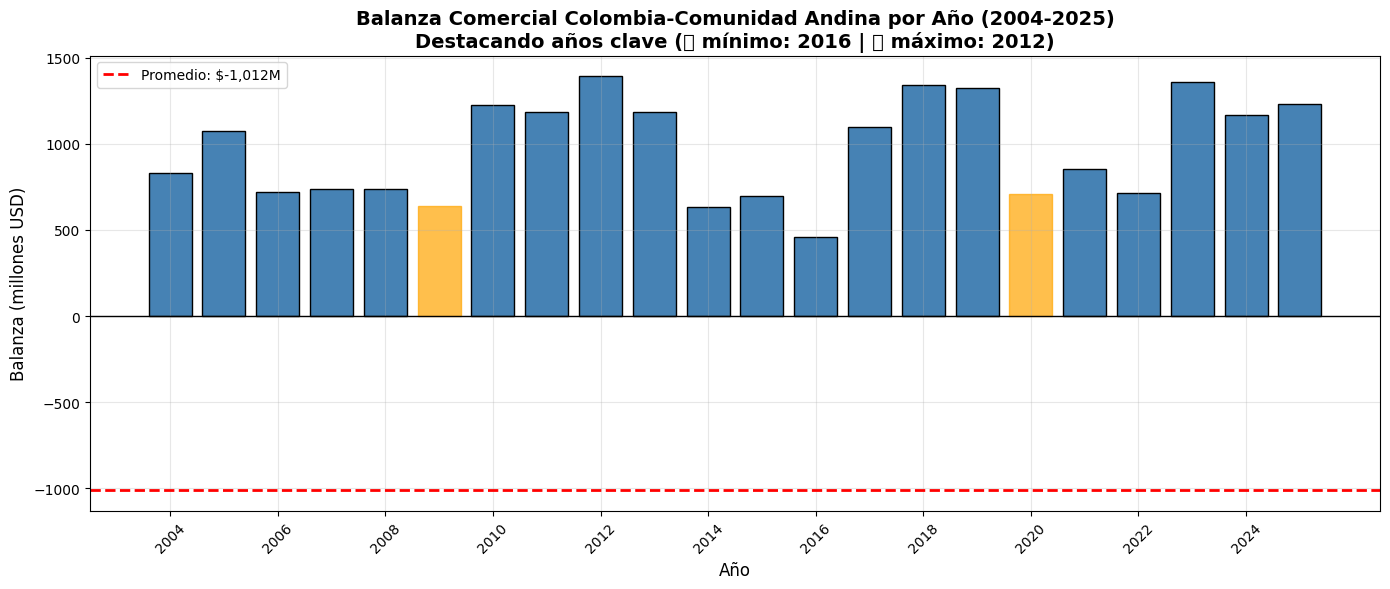

In [44]:
# Figura 3: Años clave destacados - COMUNIDAD ANDINA
año_min_and = df_andina.loc[df_andina['Balanza_Andina'].idxmin(), 'Año']
año_max_and = df_andina.loc[df_andina['Balanza_Andina'].idxmax(), 'Año']

plt.figure(figsize=(14, 6))
bars = plt.bar(df_andina['Año'], df_andina['Balanza_Andina'], color='steelblue', edgecolor='black')

for i, (año, valor) in enumerate(zip(df_andina['Año'], df_andina['Balanza_Andina'])):
    if valor == estadisticas['min']:
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.9)
    elif valor == estadisticas['max']:
        bars[i].set_color('darkgreen')
        bars[i].set_alpha(0.9)
    elif año in [2009, 2020]:  # Años de caída (crisis financiera y COVID)
        bars[i].set_color('orange')
        bars[i].set_alpha(0.7)

plt.axhline(estadisticas['mean'], color='red', linestyle='--', linewidth=2,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title(f'Balanza Comercial Colombia-Comunidad Andina por Año (2004-2025)\nDestacando años clave (🔴 mínimo: {año_min_and} | 🟢 máximo: {año_max_and})',
          fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_395/2078105240.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_395/2078105240.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


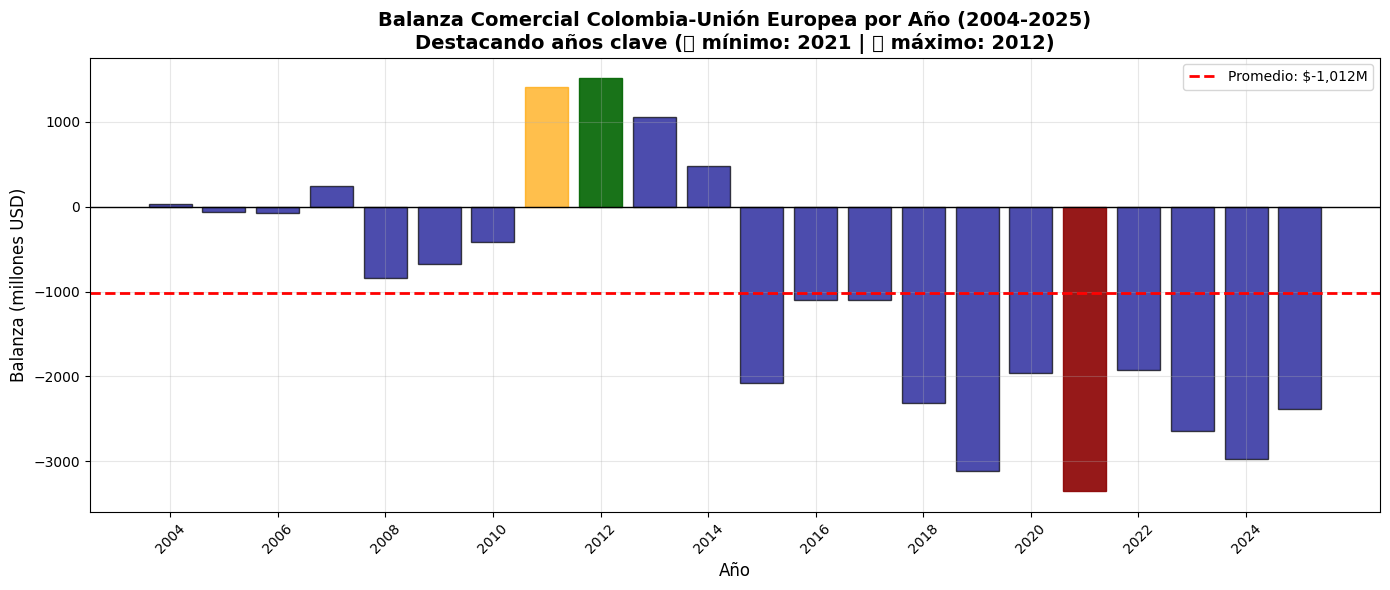

In [45]:
# Figura 3: Años clave destacados - UNIÓN EUROPEA
año_min_ue = df_ue.loc[df_ue['Balanza_UE'].idxmin(), 'Año']
año_max_ue = df_ue.loc[df_ue['Balanza_UE'].idxmax(), 'Año']

plt.figure(figsize=(14, 6))
bars = plt.bar(df_ue['Año'], df_ue['Balanza_UE'], color='darkblue', edgecolor='black', alpha=0.7)

for i, (año, valor) in enumerate(zip(df_ue['Año'], df_ue['Balanza_UE'])):
    if valor == estadisticas['min']:
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.9)
    elif valor == estadisticas['max']:
        bars[i].set_color('darkgreen')
        bars[i].set_alpha(0.9)
    elif año in [2011, 2012]:  # Años de superávit destacados
        bars[i].set_color('orange')
        bars[i].set_alpha(0.7)

plt.axhline(estadisticas['mean'], color='red', linestyle='--', linewidth=2,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title(f'Balanza Comercial Colombia-Unión Europea por Año (2004-2025)\nDestacando años clave (🔴 mínimo: {año_min_ue} | 🟢 máximo: {año_max_ue})',
          fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_395/1016778874.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_395/1016778874.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


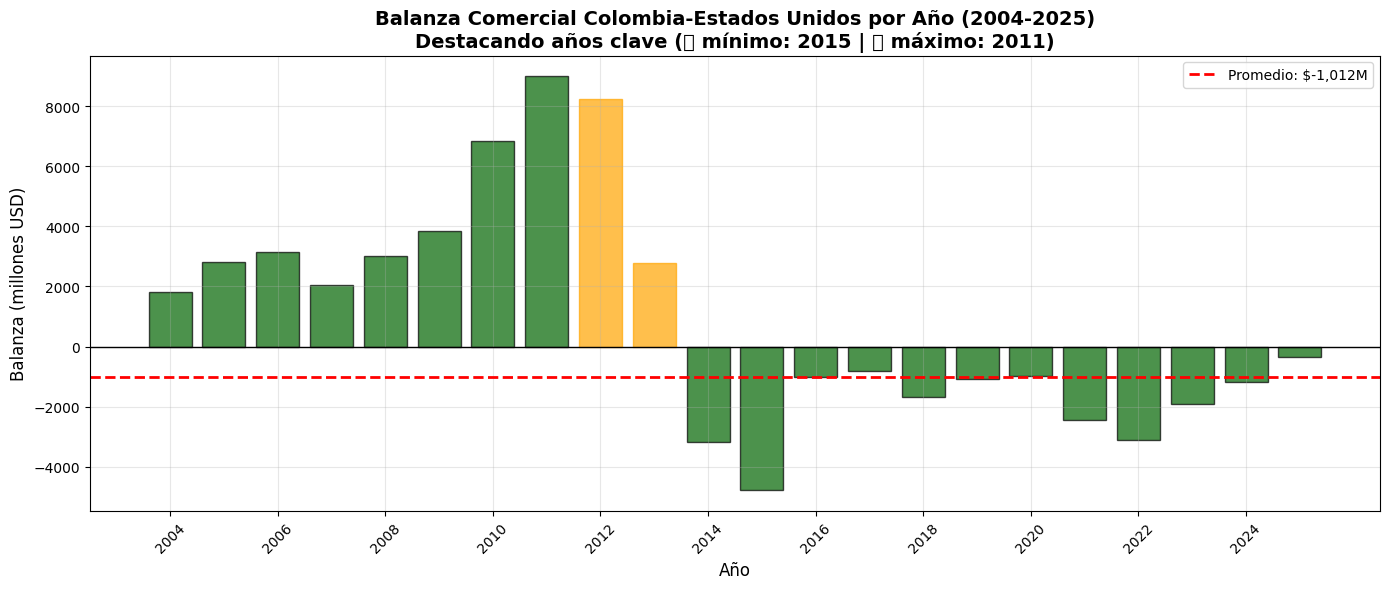

In [46]:
# Figura 3: Años clave destacados - ESTADOS UNIDOS
año_min_eeuu = df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmin(), 'Año']
año_max_eeuu = df_eeuu.loc[df_eeuu['Balanza_EEUU'].idxmax(), 'Año']

plt.figure(figsize=(14, 6))
bars = plt.bar(df_eeuu['Año'], df_eeuu['Balanza_EEUU'], color='darkgreen', edgecolor='black', alpha=0.7)

for i, (año, valor) in enumerate(zip(df_eeuu['Año'], df_eeuu['Balanza_EEUU'])):
    if valor == estadisticas['min']:
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.9)
    elif valor == estadisticas['max']:
        bars[i].set_color('gold')
        bars[i].set_alpha(0.9)
    elif año in [2012, 2013]:  # Punto de inflexión superávit a déficit
        bars[i].set_color('orange')
        bars[i].set_alpha(0.7)

plt.axhline(estadisticas['mean'], color='red', linestyle='--', linewidth=2,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title(f'Balanza Comercial Colombia-Estados Unidos por Año (2004-2025)\nDestacando años clave (🔴 mínimo: {año_min_eeuu} | 🟢 máximo: {año_max_eeuu})',
          fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_395/853630397.py:29: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_395/853630397.py:29: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


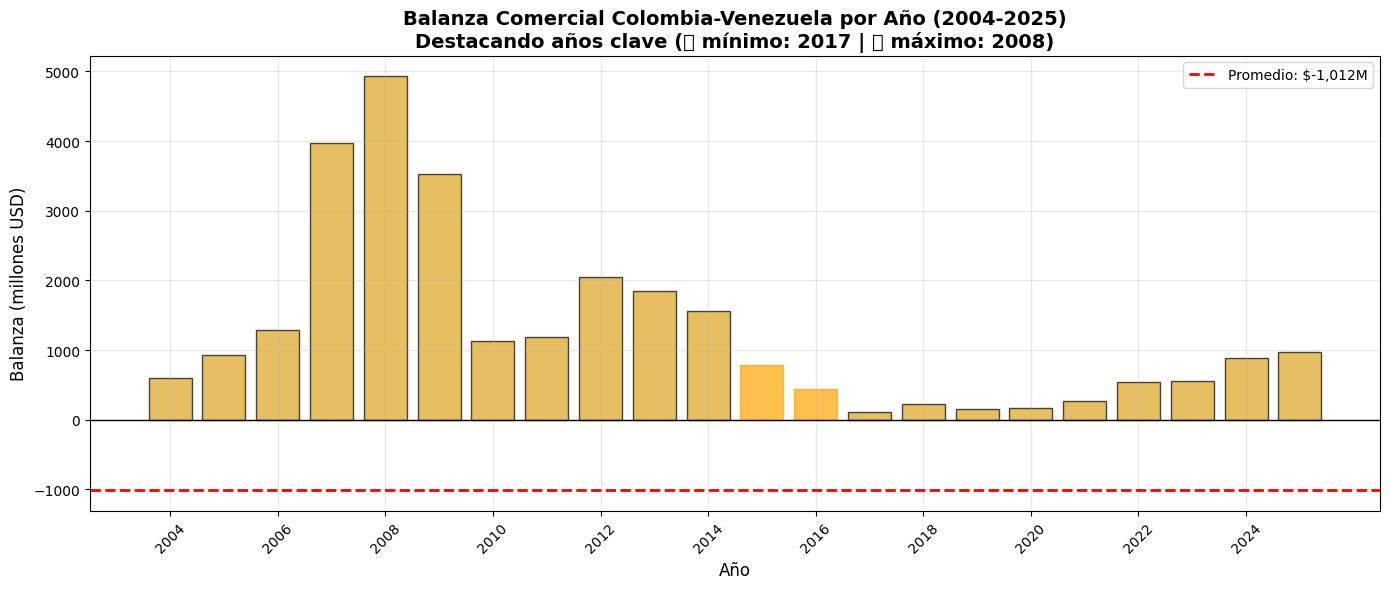

In [47]:
# Figura 3: Años clave destacados - VENEZUELA
año_min_ven = df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmin(), 'Año']
año_max_ven = df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmax(), 'Año']

plt.figure(figsize=(14, 6))
bars = plt.bar(df_venezuela['Año'], df_venezuela['Balanza_Venezuela'], color='goldenrod', edgecolor='black', alpha=0.7)

for i, (año, valor) in enumerate(zip(df_venezuela['Año'], df_venezuela['Balanza_Venezuela'])):
    if valor == estadisticas['min']:
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.9)
    elif valor == estadisticas['max']:
        bars[i].set_color('darkgreen')
        bars[i].set_alpha(0.9)
    elif año in [2015, 2016]:  # Colapso del comercio bilateral
        bars[i].set_color('orange')
        bars[i].set_alpha(0.7)

plt.axhline(estadisticas['mean'], color='red', linestyle='--', linewidth=2,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title(f'Balanza Comercial Colombia-Venezuela por Año (2004-2025)\nDestacando años clave (🔴 mínimo: {año_min_ven} | 🟢 máximo: {año_max_ven})',
          fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
# ============================================
# 6. RESUMEN EJECUTIVO GENERAL - TODOS LOS SOCIOS
# ============================================

# Recalcular estadísticas de cada socio
est_mexico    = {'mean': df_mexico['Balanza_Mexico'].mean(), 'min': df_mexico['Balanza_Mexico'].min(), 'max': df_mexico['Balanza_Mexico'].max(), 'percentil_25': df_mexico['Balanza_Mexico'].quantile(0.25), 'percentil_75': df_mexico['Balanza_Mexico'].quantile(0.75), 'percentil_50': df_mexico['Balanza_Mexico'].quantile(0.50)}
est_andina    = {'mean': df_andina['Balanza_Andina'].mean(), 'min': df_andina['Balanza_Andina'].min(), 'max': df_andina['Balanza_Andina'].max(), 'percentil_25': df_andina['Balanza_Andina'].quantile(0.25), 'percentil_75': df_andina['Balanza_Andina'].quantile(0.75), 'percentil_50': df_andina['Balanza_Andina'].quantile(0.50)}
est_ue        = {'mean': df_ue['Balanza_UE'].mean(), 'min': df_ue['Balanza_UE'].min(), 'max': df_ue['Balanza_UE'].max(), 'percentil_25': df_ue['Balanza_UE'].quantile(0.25), 'percentil_75': df_ue['Balanza_UE'].quantile(0.75), 'percentil_50': df_ue['Balanza_UE'].quantile(0.50)}
est_eeuu      = {'mean': df_eeuu['Balanza_EEUU'].mean(), 'min': df_eeuu['Balanza_EEUU'].min(), 'max': df_eeuu['Balanza_EEUU'].max(), 'percentil_25': df_eeuu['Balanza_EEUU'].quantile(0.25), 'percentil_75': df_eeuu['Balanza_EEUU'].quantile(0.75), 'percentil_50': df_eeuu['Balanza_EEUU'].quantile(0.50)}
est_venezuela = {'mean': df_venezuela['Balanza_Venezuela'].mean(), 'min': df_venezuela['Balanza_Venezuela'].min(), 'max': df_venezuela['Balanza_Venezuela'].max(), 'percentil_25': df_venezuela['Balanza_Venezuela'].quantile(0.25), 'percentil_75': df_venezuela['Balanza_Venezuela'].quantile(0.75), 'percentil_50': df_venezuela['Balanza_Venezuela'].quantile(0.50)}

# Clasificación automática de cada socio
def clasificar(df, col):
    if (df[col] > 0).all():
        return "✅ SUPERÁVIT ESTRUCTURAL"
    elif (df[col] < 0).all():
        return "🔴 DÉFICIT ESTRUCTURAL"
    else:
        n_sup = (df[col] > 0).sum()
        n_def = (df[col] < 0).sum()
        return f"⚠️  MIXTA ({n_sup} superávit / {n_def} déficit)"

tipo_mexico    = clasificar(df_mexico,    'Balanza_Mexico')
tipo_andina    = clasificar(df_andina,    'Balanza_Andina')
tipo_ue        = clasificar(df_ue,        'Balanza_UE')
tipo_eeuu      = clasificar(df_eeuu,      'Balanza_EEUU')
tipo_venezuela = clasificar(df_venezuela, 'Balanza_Venezuela')

print("\n" + "=" * 70)
print("📋 RESUMEN EJECUTIVO GENERAL — BALANZA COMERCIAL DE COLOMBIA (2004-2025)")
print("=" * 70)

print(f"""
PERÍODO ANALIZADO: 2004-2025 (22 años) | 5 socios comerciales

{'─' * 70}
🌎 PANORAMA GENERAL POR SOCIO COMERCIAL
{'─' * 70}

  1. MÉXICO             → {tipo_mexico}
     • Promedio anual : US${est_mexico['mean']:>10,.0f} M
     • Rango típico   : US${est_mexico['percentil_25']:,.0f} M  a  US${est_mexico['percentil_75']:,.0f} M
     • Peor año       : US${est_mexico['min']:,.0f} M  |  Mejor año: US${est_mexico['max']:,.0f} M

  2. COMUNIDAD ANDINA   → {tipo_andina}
     • Promedio anual : US${est_andina['mean']:>10,.0f} M
     • Rango típico   : US${est_andina['percentil_25']:,.0f} M  a  US${est_andina['percentil_75']:,.0f} M
     • Peor año       : US${est_andina['min']:,.0f} M  |  Mejor año: US${est_andina['max']:,.0f} M

  3. UNIÓN EUROPEA      → {tipo_ue}
     • Promedio anual : US${est_ue['mean']:>10,.0f} M
     • Rango típico   : US${est_ue['percentil_25']:,.0f} M  a  US${est_ue['percentil_75']:,.0f} M
     • Peor año       : US${est_ue['min']:,.0f} M  |  Mejor año: US${est_ue['max']:,.0f} M

  4. ESTADOS UNIDOS     → {tipo_eeuu}
     • Promedio anual : US${est_eeuu['mean']:>10,.0f} M
     • Rango típico   : US${est_eeuu['percentil_25']:,.0f} M  a  US${est_eeuu['percentil_75']:,.0f} M
     • Peor año       : US${est_eeuu['min']:,.0f} M  |  Mejor año: US${est_eeuu['max']:,.0f} M

  5. VENEZUELA          → {tipo_venezuela}
     • Promedio anual : US${est_venezuela['mean']:>10,.0f} M
     • Rango típico   : US${est_venezuela['percentil_25']:,.0f} M  a  US${est_venezuela['percentil_75']:,.0f} M
     • Peor año       : US${est_venezuela['min']:,.0f} M  |  Mejor año: US${est_venezuela['max']:,.0f} M

{'─' * 70}
🔍 CONCLUSIONES ESTRATÉGICAS
{'─' * 70}

✅ SOCIOS DEFICITARIOS (Colombia importa más de lo que exporta):
   → México y Unión Europea representan déficits estructurales
     sostenidos durante todo el período.

✅ SOCIO MÁS FAVORABLE:
   → La Comunidad Andina es el único bloque con superávit
     PERMANENTE para Colombia en los 22 años analizados.

✅ CASO ESPECIAL — VENEZUELA:
   → Pasó de ser el 2do socio más superavitario (pico en 2008
     con US${df_venezuela.loc[df_venezuela['Balanza_Venezuela'].idxmax(), 'Balanza_Venezuela']:,.0f} M)
     a niveles mínimos tras la crisis política y económica.

✅ CASO ESPECIAL — ESTADOS UNIDOS:
   → Hubo un punto de inflexión estructural: de superávit
     (2004-2013) a déficit sostenido (2014-2025), coincidiendo
     con la caída de precios del petróleo.

✅ RECOMENDACIÓN DE POLÍTICA COMERCIAL:
   → Profundizar exportaciones hacia la Comunidad Andina
     y Venezuela (mercado en recuperación).
   → Diversificar canasta exportadora hacia México y UE
     para reducir déficits estructurales.
   → Monitorear la relación con EE.UU. dado su peso
     histórico y el cambio de tendencia post-2013.
""")

print("✅ ANÁLISIS GENERAL COMPLETO")


📋 RESUMEN EJECUTIVO GENERAL — BALANZA COMERCIAL DE COLOMBIA (2004-2025)

PERÍODO ANALIZADO: 2004-2025 (22 años) | 5 socios comerciales

──────────────────────────────────────────────────────────────────────
🌎 PANORAMA GENERAL POR SOCIO COMERCIAL
──────────────────────────────────────────────────────────────────────

  1. MÉXICO             → 🔴 DÉFICIT ESTRUCTURAL
     • Promedio anual : US$    -2,448 M
     • Rango típico   : US$-2,720 M  a  US$-1,665 M
     • Peor año       : US$-5,399 M  |  Mejor año: US$-470 M

  2. COMUNIDAD ANDINA   → ✅ SUPERÁVIT ESTRUCTURAL
     • Promedio anual : US$       969 M
     • Rango típico   : US$718 M  a  US$1,217 M
     • Peor año       : US$460 M  |  Mejor año: US$1,393 M

  3. UNIÓN EUROPEA      → ⚠️  MIXTA (6 superávit / 16 déficit)
     • Promedio anual : US$    -1,012 M
     • Rango típico   : US$-2,252 M  a  US$10 M
     • Peor año       : US$-3,352 M  |  Mejor año: US$1,514 M

  4. ESTADOS UNIDOS     → ⚠️  MIXTA (10 superávit / 12 déficit)
   